In [111]:
from google.colab import drive # remove the cell if not using colab
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [112]:
import pandas as pd
import numpy as np
import seaborn as sns
from pathlib import Path
from matplotlib import pyplot as plt
base_path = Path("/content/drive/MyDrive/wakacyjne_wyzwanie_solvro") # change to path folder with data


# Analiza i przetwarzanie danych na temat Titanica

#### Wyobraź sobie, że pewnego wakacyjnego dnia, będąc na plaży w pełnym słońcu, odbierasz telefon od nieznanego numeru.
Robisz to niechętnie — zasłużyłeś/aś przecież na odpoczynek i chcesz mieć ten czas tylko dla siebie. Już masz na końcu języka wymijającą odpowiedź, gdy nagle z drugiej strony słyszysz:
„Czy jesteś gotowy, by tego lata rozwikłać jedną z największych zagadek ludzkości?”

Jako osoba z natury ciekawa świata i ze świetnym umysłem analitycznym, szybko zapominasz o plaży i wakacjach. Zaintrygowany/a dopytujesz o szczegóły, ale rozmówca nie chce zdradzić zbyt wiele. Wiadomo jedynie, że chodzi o *zatonięcie Titanica w 1914* roku, a celem misji jest ustalenie, które osoby miały szansę przeżyć.

**Ty** — jako **renomowany analityk danych** — byłeś/byłaś ich pierwszym wyborem do analizy i oczyszczenia danych. Mimo wątpliwości postanawiasz podjąć się zadania, mając nadzieję, że twoja wiedza może zostać praktycznie wykorzystana w słusznym celu.

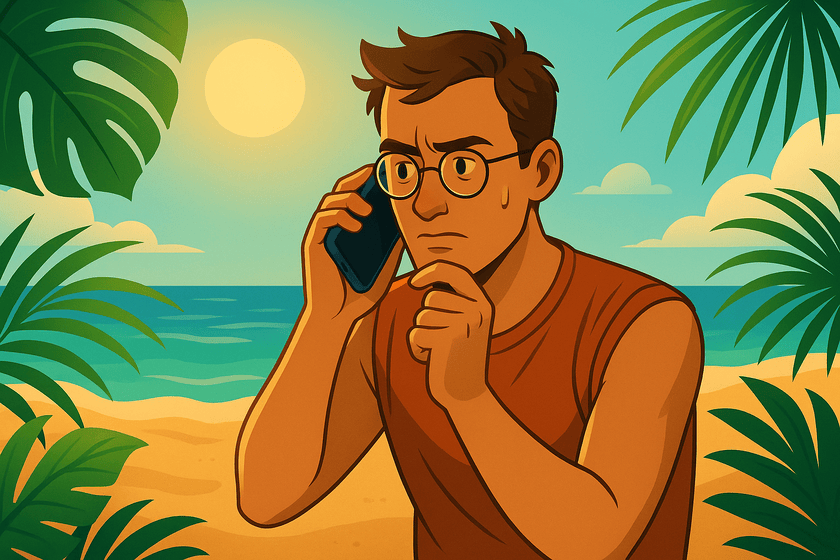

(*AI-generated image*)


#### Twoim celem będzie przeanalizowanie i przetworzenie zbioru danych w taki sposób, by mógł on być użyty do nauki modelu do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

(Uwaga: w tym zadaniu nie będziesz trenować modeli, ta przyjemność spotka cię w następnych notebookach)

Poniżej znajdziesz pytania, które mogą być pomocne w analizie, oraz odwołania do poszczególnych sekcji z notebooka do lekcji:

- Czy wszystkie kolumny są istotne w kontekście zadania?
- Czy występują brakujące wartości? Jeśli tak, to jak je uzupełnisz? (sekcja #2.1)
- Czy typy danych są odpowiednie do znaczenia kolumny? (sekcja #1.3)
- Czy dystrybucje danych mają rozkłady normalne, czy asymetryczne? (sekcja #4.1 + wykład)
- Która zmienna oznacza predykowaną klasę?
- Jaki jest rozkład zmiennej predykowanej względem zmiennych kategorialnych, jak i numerycznych? (sekcja #4.1)
- Czy końcowe rozkłady zawierają wartości skrajne? (sekcja #4.2 + wykład)

Wymagania:

- Zbiór musi być oczyszczony, tj. finalnie nie powinien mieć brakujących wartości (sekcja #2.1)
- Zbiór musi zawierać co najmniej dwie dodatkowe kolumny, które mogą wzbogacić informacje zawarte w zbiorze (sekcje #1.5 i #2.2)
- Cechy kategorialne powinny być zakodowane, postaraj się dobrać odpowiedni sposób (sekcja #2.3)
- Zbadaj, czy występują skrajne wartości (outliery) zarówno dla wartości numerycznych, jak i dla kategorialnych
- Każda cecha powinna być zwizualizowana co najmniej raz. Sam(a) zastanów się, czy warto wizualizować cechy parami w celu odkrycia zależności między nimi (sekcja #4.4)
- Nie ma ograniczenia na liczbę komórek, ale zastanów się, czy dana wizualizacja/obliczenie jest przydatne w całej analizie, czy po prostu sobie "egzystuje" bez żadnych wniosków

Zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Poniżej zamieszczamy tabelę z wyjaśnieniem poszczególnych kolumn:

| Kolumna      | Opis                                                                            |
| ------------ | ------------------------------------------------------------------------------- |
| **Survived** | Czy pasażer przeżył (0 = nie, 1 = tak).                                         |
| **Pclass**   | Klasa podróży (1 = I klasa, 2 = II klasa, 3 = III klasa).                       |
| **Name**     | Imię i nazwisko pasażera.                                                       |
| **Sex**      | Płeć pasażera (male = mężczyzna, female = kobieta).                             |
| **Age**      | Wiek pasażera w latach.                                                         |
| **SibSp**    | Liczba rodzeństwa i małżonków na pokładzie.                                     |
| **Parch**    | Liczba rodziców i dzieci na pokładzie.                                          |
| **Ticket**   | Numer biletu.                                                                   |
| **Fare**     | Cena biletu.                                                                    |
| **Cabin**    | Numer kabiny pasażera                                     |
| **Embarked** | Port, w którym pasażer wsiadł (C = Cherbourg, Q = Queenstown, S = Southampton). |
                                                         |


In [113]:
titanic_df = pd.read_csv(base_path / 'titanic.csv', index_col='PassengerId')
titanic_df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S


### Usuwanie kolumn
Zdecydowałem się usunąć następujące kolumny:
- Name (imię i nazwisko jest zbędną zmienną kategorialną, która nie daje nam żadnych dodatkowych informacji),
- Ticket (numer biletu to identyfikator, który nie przenosi żadnych informacji o konkretnej osobie),

In [114]:
titanic_df = titanic_df.drop(columns=['Name', 'Ticket'])
titanic_df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
PassengerId,,,,,,,,,
1,0,3,male,22.0,1,0,7.2500,NaN,S
2,1,1,female,38.0,1,0,71.2833,C85,C
3,1,3,female,26.0,0,0,7.9250,NaN,S
4,1,1,female,35.0,1,0,53.1000,C123,S
5,0,3,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...
887,0,2,male,27.0,0,0,13.0000,NaN,S
888,1,1,female,19.0,0,0,30.0000,B42,S
889,0,3,female,NaN,1,2,23.4500,NaN,S


### Kolumna Cabin
Możemy zauważyć, że w kolumnie Cabin 77% wartości jest brakujące. Wynika to z faktu, iż tylko pasażerowie 1 klasy mieli kabinę. Dodatkowo niektóre osoby mają przypisane do siebie kilka kabin. Rodzieliłem zatem kolumnę Cabin na kolumny: Cabin Count - ilość posiadanych kabin, Cabin Letter - literka w oznaczeniu kabiny, First Cabin Num - numer pierwszej posiadanej kabiny

In [115]:
titanic_df['Cabin'].isna().sum()/titanic_df.shape[0]

np.float64(0.7710437710437711)

Widać, że kabiny są wypisane w różny sposób. Litera z numerem, lista kilku kabin lub sama litera. W przypadku kabin bez numeru zdecydowałem się usunąć wiersze, które je zawierają.

In [116]:
print(titanic_df['Cabin'][28])
print(titanic_df['Cabin'][129])
print(titanic_df['Cabin'][28])
print(titanic_df['Cabin'][340])
print(titanic_df['Cabin'].str[0].unique())

C23 C25 C27
F E69
C23 C25 C27
T
[nan 'C' 'E' 'G' 'D' 'A' 'B' 'F' 'T']


In [117]:
titanic_df['Cabin']=titanic_df['Cabin'].fillna('Unknown')
titanic_df['Cabin']

,Cabin
PassengerId,
1,Unknown
2,C85
3,Unknown
4,C123
5,Unknown
...,...
887,Unknown
888,B42
889,Unknown


Usunięcie indeksów z kabinami bez numeru

In [118]:
no_number = titanic_df['Cabin'].apply(lambda x: len(x.split()[0])==1)
no_number_indexes = titanic_df[no_number].index
titanic_df=titanic_df.drop(no_number_indexes)
titanic_df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
PassengerId,,,,,,,,,
1,0,3,male,22.0,1,0,7.2500,Unknown,S
2,1,1,female,38.0,1,0,71.2833,C85,C
3,1,3,female,26.0,0,0,7.9250,Unknown,S
4,1,1,female,35.0,1,0,53.1000,C123,S
5,0,3,male,35.0,0,0,8.0500,Unknown,S
...,...,...,...,...,...,...,...,...,...
887,0,2,male,27.0,0,0,13.0000,Unknown,S
888,1,1,female,19.0,0,0,30.0000,B42,S
889,0,3,female,NaN,1,2,23.4500,Unknown,S


In [119]:
(titanic_df['Cabin'].str[1]==' ').sum()

np.int64(0)

Dodanie kolumny Cabin Letter

In [121]:
cabin_letters=titanic_df['Cabin'].str[0]
cabin_letters = cabin_letters.apply(lambda x: 'Unknown' if x=='U' else x)
titanic_df.loc[:, 'Cabin Letter'] = cabin_letters

In [122]:
titanic_df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Cabin Letter
PassengerId,,,,,,,,,,
1,0,3,male,22.0,1,0,7.2500,Unknown,S,Unknown
2,1,1,female,38.0,1,0,71.2833,C85,C,C
3,1,3,female,26.0,0,0,7.9250,Unknown,S,Unknown
4,1,1,female,35.0,1,0,53.1000,C123,S,C
5,0,3,male,35.0,0,0,8.0500,Unknown,S,Unknown
...,...,...,...,...,...,...,...,...,...,...
887,0,2,male,27.0,0,0,13.0000,Unknown,S,Unknown
888,1,1,female,19.0,0,0,30.0000,B42,S,B
889,0,3,female,NaN,1,2,23.4500,Unknown,S,Unknown


Dodanie kolumny Cabin Count

In [123]:
num_cabins = titanic_df['Cabin'].apply(lambda x: len(x.split()) if x!='Unknown' else 0)
titanic_df.loc[:, 'Cabin Count'] = num_cabins
titanic_df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Cabin Letter,Cabin Count
PassengerId,,,,,,,,,,,
1,0,3,male,22.0,1,0,7.2500,Unknown,S,Unknown,0
2,1,1,female,38.0,1,0,71.2833,C85,C,C,1
3,1,3,female,26.0,0,0,7.9250,Unknown,S,Unknown,0
4,1,1,female,35.0,1,0,53.1000,C123,S,C,1
5,0,3,male,35.0,0,0,8.0500,Unknown,S,Unknown,0
...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,male,27.0,0,0,13.0000,Unknown,S,Unknown,0
888,1,1,female,19.0,0,0,30.0000,B42,S,B,1
889,0,3,female,NaN,1,2,23.4500,Unknown,S,Unknown,0


Dodanie kolumny First Cabin Num (brak kabiny zmapowałem na -1)



In [125]:
first_cabin_nums = titanic_df['Cabin'].apply(lambda x: x.split()[0][1:] if x!='Unknown' else '-1')
titanic_df.loc[:, 'First Cabin Num'] = first_cabin_nums.astype(int)
titanic_df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Cabin Letter,Cabin Count,First Cabin Num
PassengerId,,,,,,,,,,,,
1,0,3,male,22.0,1,0,7.2500,Unknown,S,Unknown,0,-1
2,1,1,female,38.0,1,0,71.2833,C85,C,C,1,85
3,1,3,female,26.0,0,0,7.9250,Unknown,S,Unknown,0,-1
4,1,1,female,35.0,1,0,53.1000,C123,S,C,1,123
5,0,3,male,35.0,0,0,8.0500,Unknown,S,Unknown,0,-1
...,...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,male,27.0,0,0,13.0000,Unknown,S,Unknown,0,-1
888,1,1,female,19.0,0,0,30.0000,B42,S,B,1,42
889,0,3,female,NaN,1,2,23.4500,Unknown,S,Unknown,0,-1


Usunięcie kolumny Cabin

In [126]:
titanic_df = titanic_df.drop(columns=['Cabin'])
titanic_df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Cabin Letter,Cabin Count,First Cabin Num
PassengerId,,,,,,,,,,,
1,0,3,male,22.0,1,0,7.2500,S,Unknown,0,-1
2,1,1,female,38.0,1,0,71.2833,C,C,1,85
3,1,3,female,26.0,0,0,7.9250,S,Unknown,0,-1
4,1,1,female,35.0,1,0,53.1000,S,C,1,123
5,0,3,male,35.0,0,0,8.0500,S,Unknown,0,-1
...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,male,27.0,0,0,13.0000,S,Unknown,0,-1
888,1,1,female,19.0,0,0,30.0000,S,B,1,42
889,0,3,female,NaN,1,2,23.4500,S,Unknown,0,-1


### Uzupełnianie brakujących danych
- Survived: wszystkie są uzupełnione,
- Pclass: wszystkie są uzupełnione,
- Sex: wszystkie są uzupełnione,
- Age: uzupełnianie danymi z rozkładu - najlepsze rozwiązanie dla zmiennej liczbowej o rozkładzie zbliżonym do normalnego (wykres poniżej). Dodatkowo zamieniłem wartości poniżej 1 na średnią oraz zaokrągliłem wszystkie wartości do liczb całkowitych
- SibSp: wszystkie są uzupełnione,
- Parch: wszystkie są uzupełnione,
- Fare: analogicznie jak wiek - z rozkładu,
- Embarked: wypełnienie najczęstszą klasą (chociaż są tylko dwie wartości NaN, więc w skali wielkości zbioru danych niewiele to zmienia).

In [127]:
def print_value_counts(df, column):
    column_counts = df[column].value_counts()
    print(column_counts)
    print(df[column].isna().sum())

In [128]:
for column in titanic_df.columns:
    print_value_counts(titanic_df, column)

Survived
0    544
1    339
Name: count, dtype: int64
0
Pclass
3    487
1    215
2    181
Name: count, dtype: int64
0
Sex
male      572
female    311
Name: count, dtype: int64
0
Age
24.00    30
22.00    27
18.00    26
28.00    25
30.00    25
         ..
24.50     1
0.67      1
0.42      1
34.50     1
74.00     1
Name: count, Length: 88, dtype: int64
176
SibSp
0    601
1    208
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64
0
Parch
0    671
1    117
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64
0
Fare
8.0500     37
13.0000    37
7.8958     34
7.7500     30
26.0000    29
           ..
6.4375      1
39.4000     1
13.8583     1
50.4958     1
10.5167     1
Name: count, Length: 234, dtype: int64
98
Embarked
S    639
C    165
Q     77
Name: count, dtype: int64
2
Cabin Letter
Unknown    687
C           59
B           47
E           32
D           30
A           15
F            9
G            4
Name: count, dtype: int64
0
Cabin Count
0    687
1   

In [129]:
def print_column_params(column, xlabel, ylabel):
    print((titanic_df[column]<1).sum())
    age_counts = titanic_df[column].value_counts().sort_index()
    plt.figure(figsize=(20, 5))
    age_counts.plot(kind='bar')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

def fill_from_distribution(df, column):
    distribution = titanic_df[column].dropna().value_counts(normalize=True)
    values = distribution.index
    probabilities = distribution.values
    missing_vals = titanic_df[column].isna()
    titanic_df.loc[missing_vals, column] = np.random.choice(values, size=missing_vals.sum(), p=probabilities)

7


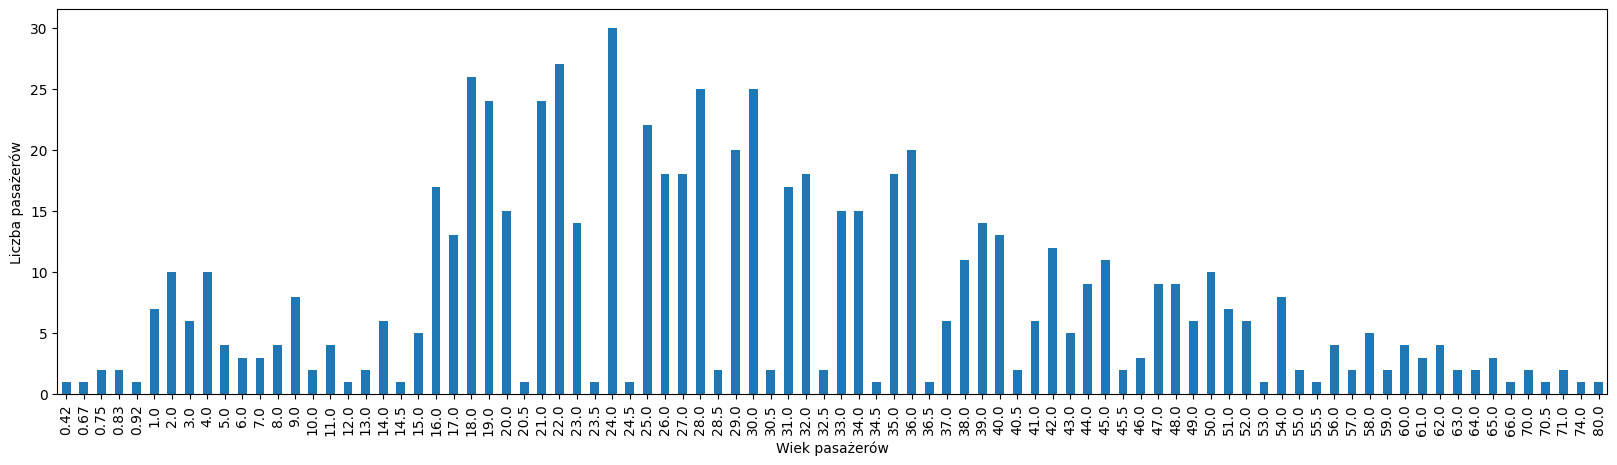

In [130]:
print_column_params('Age', 'Wiek pasażerów', 'Liczba pasażerów')

0


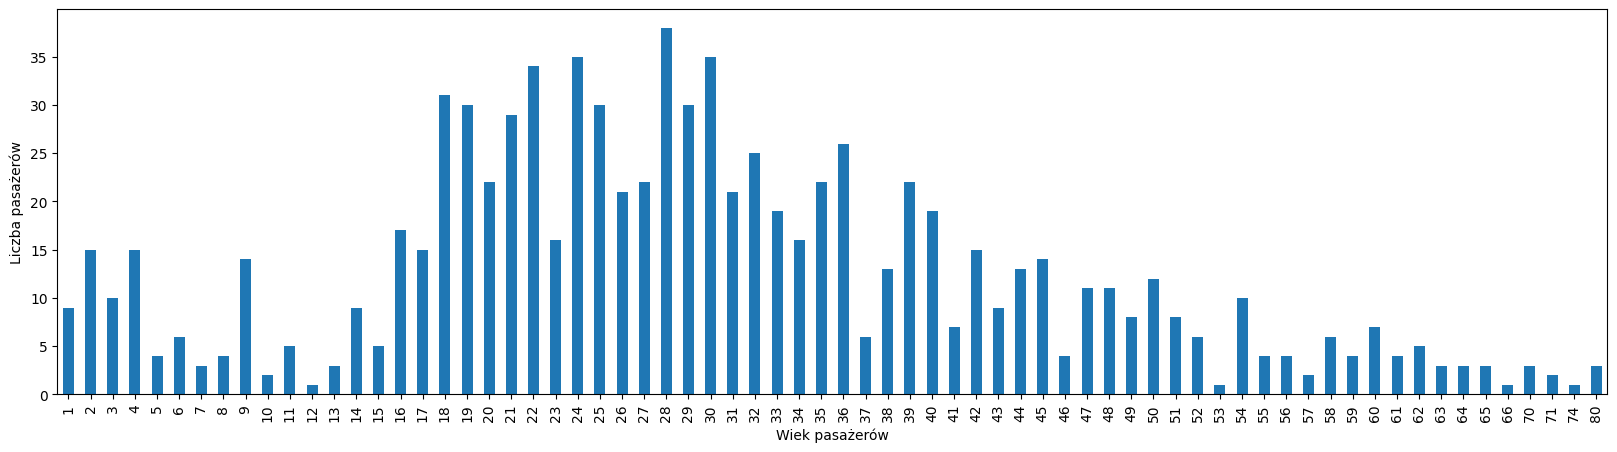

In [131]:
age_mean = int(titanic_df['Age'].mean())
fill_from_distribution(titanic_df, 'Age')
titanic_df['Age'] = titanic_df['Age'].apply(lambda x: int(x) if x >= 1 else age_mean)
print_column_params('Age', 'Wiek pasażerów', 'Liczba pasażerów')

13


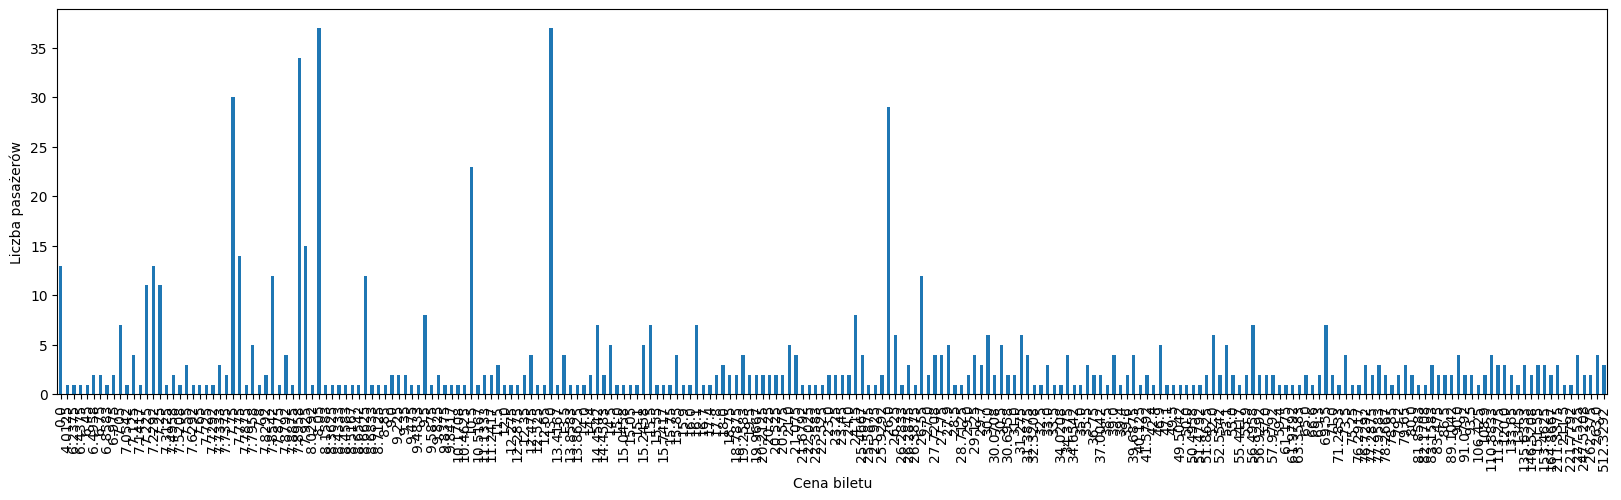

In [132]:
print_column_params('Fare', 'Cena biletu', 'Liczba pasażerów')

14


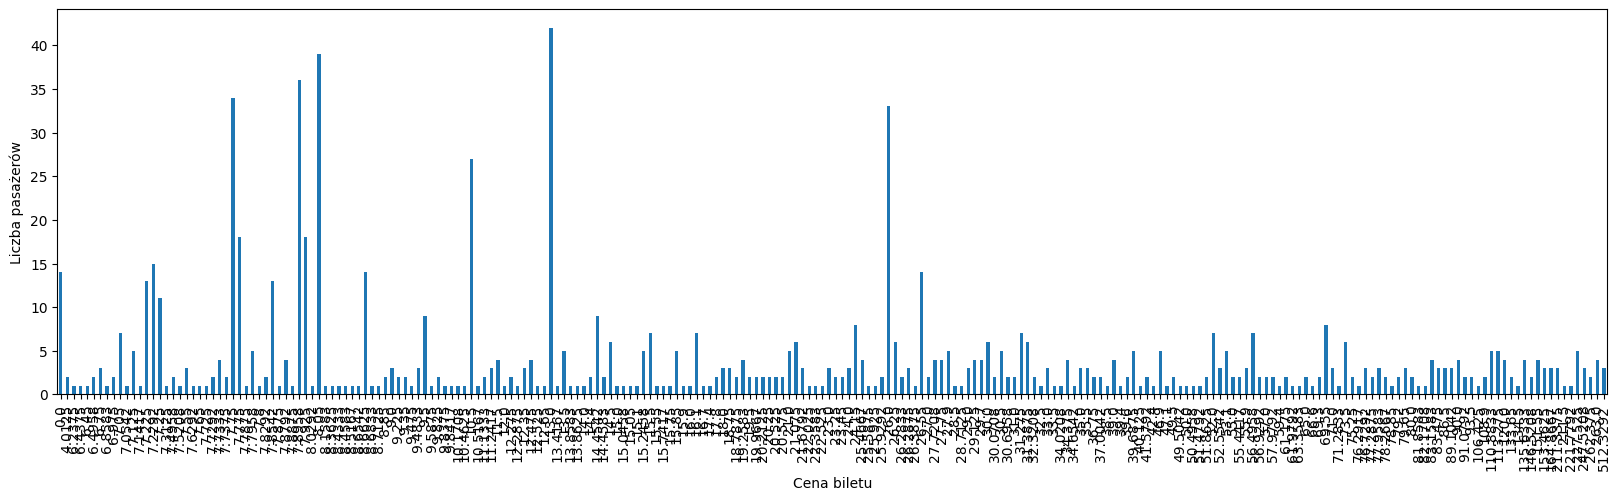

In [133]:
fill_from_distribution(titanic_df, 'Fare')
print_column_params('Fare', 'Cena biletu', 'Liczba pasażerów')

In [134]:
titanic_df['Fare'].isna().sum()

np.int64(0)

In [135]:
embarked_counts = titanic_df['Embarked'].value_counts()
embarked_counts

,count
Embarked,
S,639
C,165
Q,77


In [136]:
titanic_df['Embarked']=titanic_df['Embarked'].fillna(embarked_counts.index[0])
titanic_df['Embarked'].isna().sum()

np.int64(0)

In [137]:
titanic_df.isna().sum().any()

np.False_

In [138]:
titanic_df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Cabin Letter,Cabin Count,First Cabin Num
PassengerId,,,,,,,,,,,
1,0,3,male,22,1,0,7.2500,S,Unknown,0,-1
2,1,1,female,38,1,0,71.2833,C,C,1,85
3,1,3,female,26,0,0,7.9250,S,Unknown,0,-1
4,1,1,female,35,1,0,53.1000,S,C,1,123
5,0,3,male,35,0,0,8.0500,S,Unknown,0,-1
...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,male,27,0,0,13.0000,S,Unknown,0,-1
888,1,1,female,19,0,0,30.0000,S,B,1,42
889,0,3,female,42,1,2,23.4500,S,Unknown,0,-1


### Kodowanie cech kategorialnych

W przypadku płci zastosowałem binary encoding (oczywisty wybór z uwagi na dwie kategorie), w przypadku portu zastosowałem klasyczny one-hot encoding z uwagi na małą ilość różnych klas, co nie zwiększa drastycznie wymiarowości (dodatkowo w wywołaniu funkcji get_dummies ustawiłem parametr drop_first=True, co dodatkowo zwiększa wymiarowość, a dalej jest czytelne - w przypadku wartości 0 dla Q i S wiemy, że kategorią jest C), natomiast w przypadku Cabin Letter użyłem ordinal encoding, ponieważ uznałem, że litera kabiny może świadczyć o jej umiejscowieniu na statku, co mogło mieć znaczenie w kontekście przeżycia.

In [139]:
print(titanic_df.Sex.unique())
print(titanic_df.Embarked.unique())
print(titanic_df['Cabin Letter'].unique())

['male' 'female']
['S' 'C' 'Q']
['Unknown' 'C' 'E' 'G' 'D' 'A' 'B' 'F']


In [140]:
is_male = titanic_df['Sex'] == 'male'
titanic_df['Sex'] = is_male.astype(int)

titanic_df = pd.get_dummies(
    titanic_df,
    columns=['Embarked'],
    drop_first=True,
    dtype=int,
)

mapping = {
    'Unknown': 0,
    'A': 1,
    'B': 2,
    'C': 3,
    'D': 4,
    'E': 5,
    'F': 6,
    'G': 7,
}

titanic_df['Cabin Letter'] = titanic_df['Cabin Letter'].map(mapping)

titanic_df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin Letter,Cabin Count,First Cabin Num,Embarked_Q,Embarked_S
PassengerId,,,,,,,,,,,,
1,0,3,1,22,1,0,7.2500,0,0,-1,0,1
2,1,1,0,38,1,0,71.2833,3,1,85,0,0
3,1,3,0,26,0,0,7.9250,0,0,-1,0,1
4,1,1,0,35,1,0,53.1000,3,1,123,0,1
5,0,3,1,35,0,0,8.0500,0,0,-1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,1,27,0,0,13.0000,0,0,-1,0,1
888,1,1,0,19,0,0,30.0000,2,1,42,0,1
889,0,3,0,42,1,2,23.4500,0,0,-1,0,1


### Dodawanie nowych kolumn

Zdecydowałem się dodać kolumny:
- Is_Child, która informuje że pasażer miał mniej niż 18 lat,
- Over_three_family_members, która informuje, że pasażer miał co najmniej 3 członków rodziny na pokładzie (łącznie z nim powyżej 3).

In [141]:
is_child = titanic_df['Age'] < 18
titanic_df.loc[:, 'Is_Child'] = is_child.astype(int)

over_three_family_members = titanic_df['SibSp'] + titanic_df['Parch'] >= 3
titanic_df.loc[:, 'Over_three_family_members'] = over_three_family_members.astype(int)

### Typy
Wszystkie typy są liczbowe i dopasowane do rodzaju zmiennej

In [142]:
titanic_df.dtypes

,0
Survived,int64
Pclass,int64
Sex,int64
Age,int64
SibSp,int64
Parch,int64
Fare,float64
Cabin Letter,int64
Cabin Count,int64
First Cabin Num,int64


### Outliery i rozkłady


In [143]:
def draw_boxplot(df, column):
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[column])
    plt.title(f'Rozkład zmiennej {column}')
    plt.xlabel(column)

    plt.show()

def draw_scatterplot(df, x_column, y_column):
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=df, x=x_column, y=y_column)
    plt.title(f'{x_column} vs {y_column}')
    plt.xlabel(x_column)
    plt.ylabel(y_column)
    plt.tight_layout()
    plt.show()

def draw_barplot(df, x_column, y_column):
    plt.figure(figsize=(6, 4))
    plt.bar(data=df, x=x_column, y=y_column)
    plt.title(f'{x_column} vs {y_column}')
    plt.xlabel(x_column)
    plt.ylabel(y_column)
    plt.tight_layout()
    plt.show()

def plot_numeric_histogram(df, column_name):
    data = df[column_name]
    mean_val = data.mean()
    median_val = data.median()

    plt.figure(figsize=(6, 4))
    plt.hist(data, bins=30, color='steelblue', edgecolor='black')
    plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')

    plt.title(f'Distribution of {column_name}')
    plt.xlabel(column_name)
    plt.ylabel('Frequency')
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_correlation_matrix(df):
    corr = df.corr(numeric_only=True)

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
    plt.title('Correlation Matrix')
    plt.tight_layout()
    plt.show()

Widzimy, że w przypadku zmiennej Fare jak i SibSp mamy jeden outlier, ktoś zapłacił bardzo wysoką cenę za bilet oraz ma aż 8 rodzeństwa i małżonków na pokładzie.

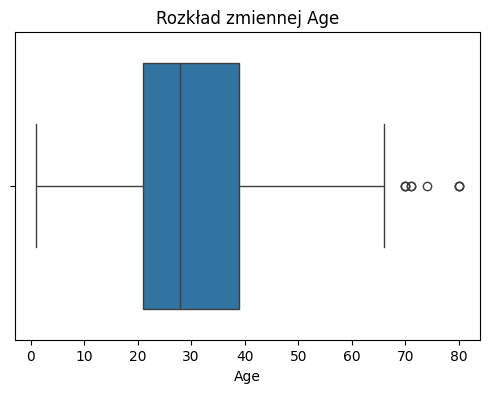

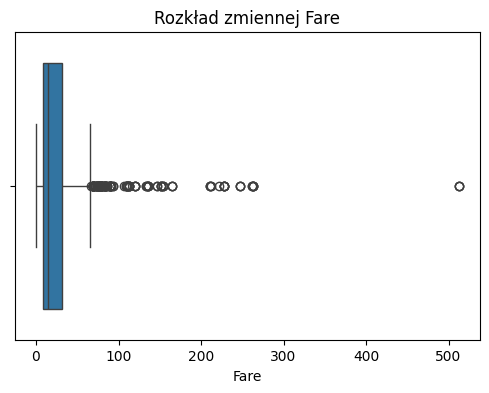

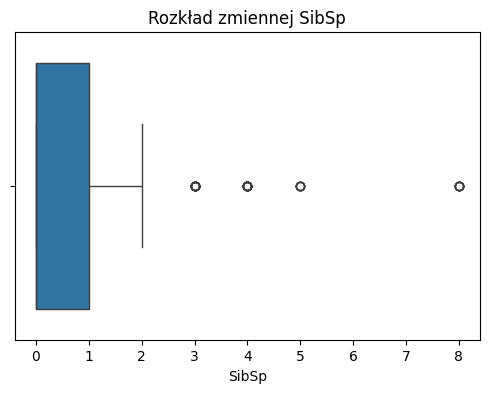

In [144]:
draw_boxplot(titanic_df, 'Age')
draw_boxplot(titanic_df, 'Fare')
draw_boxplot(titanic_df, 'SibSp')

Klasa nie jest skorelowana z opłatą, natomiast jest skorelowana z ilością kabin. Ilość rodzeństwa i małżonków jest negatywnie skorelowana z ilością rodziców i dzieci.

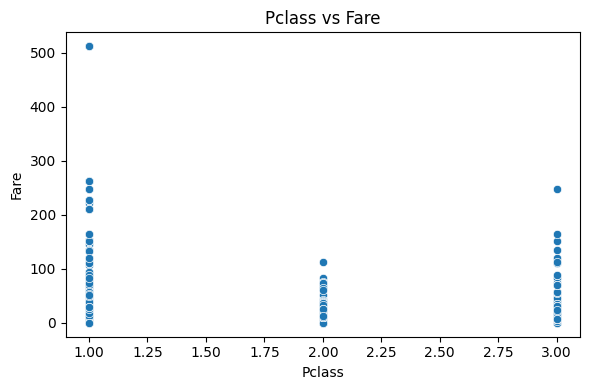

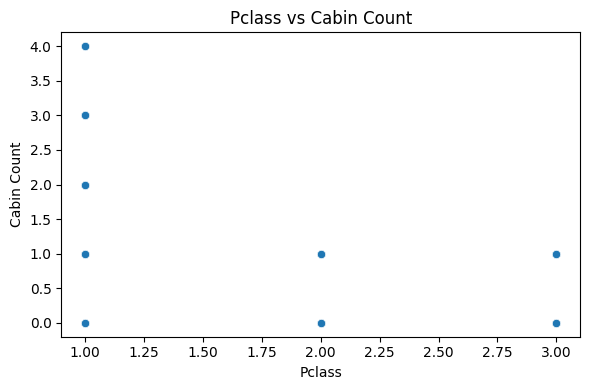

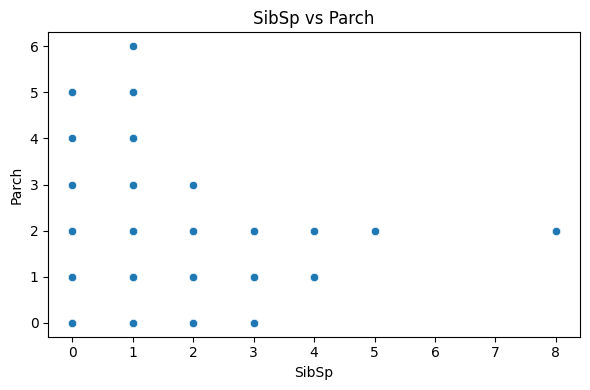

In [145]:
draw_scatterplot(titanic_df, 'Pclass', 'Fare')
draw_scatterplot(titanic_df, 'Pclass', 'Cabin Count')
draw_scatterplot(titanic_df, 'SibSp', 'Parch')

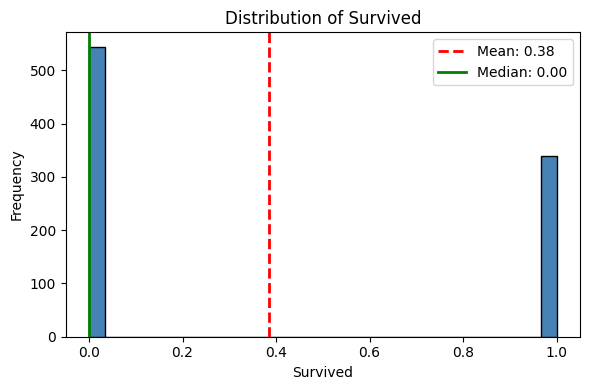

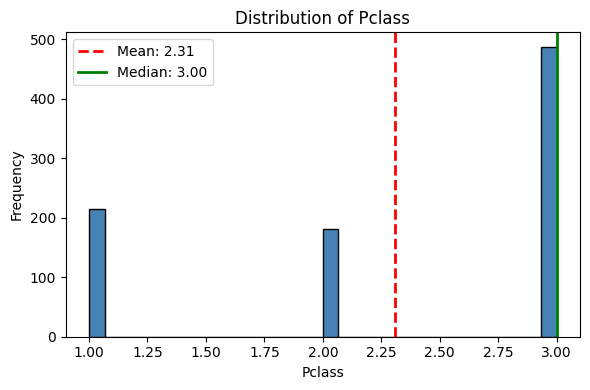

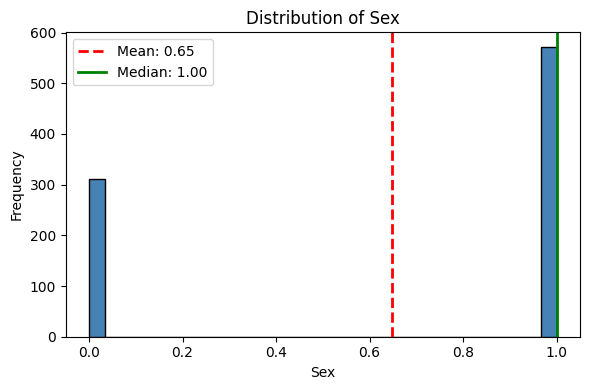

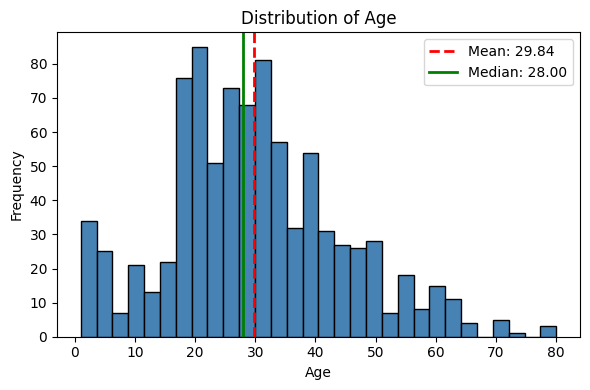

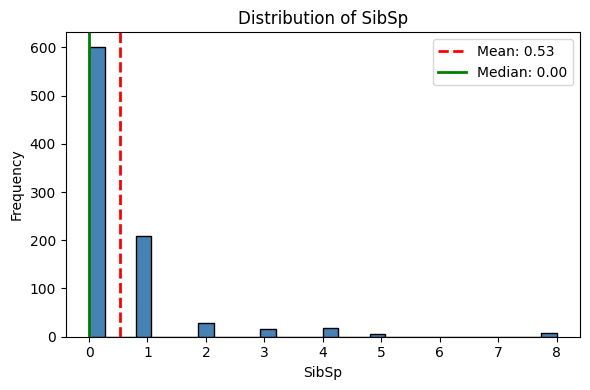

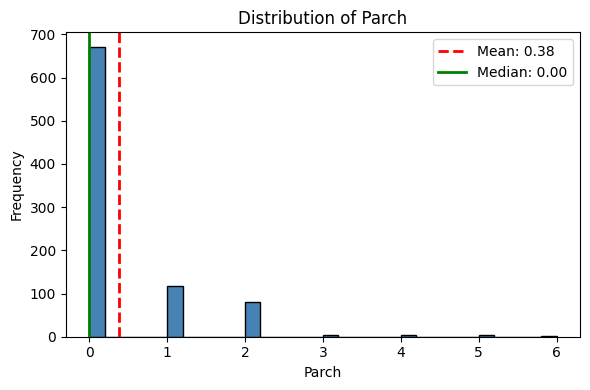

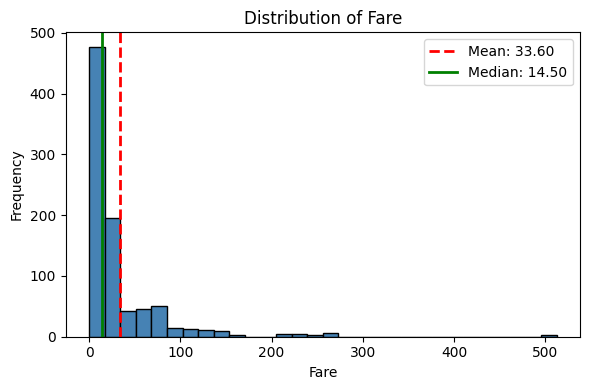

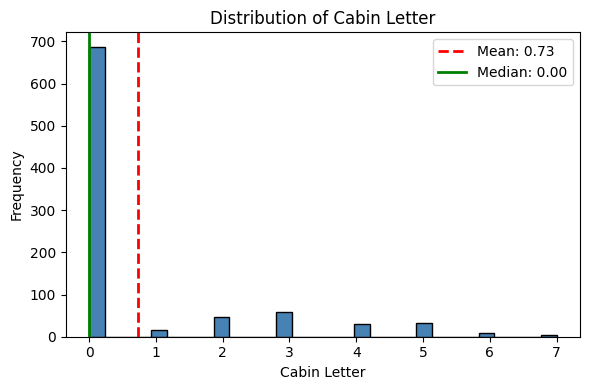

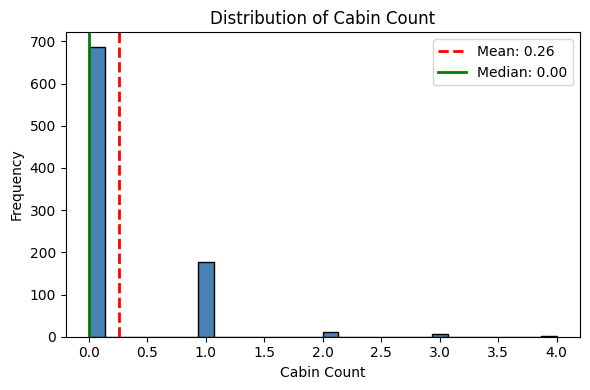

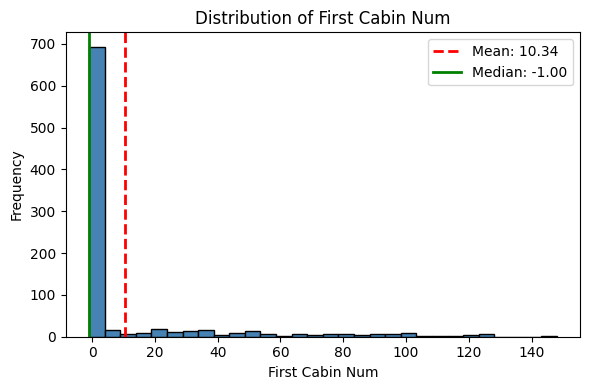

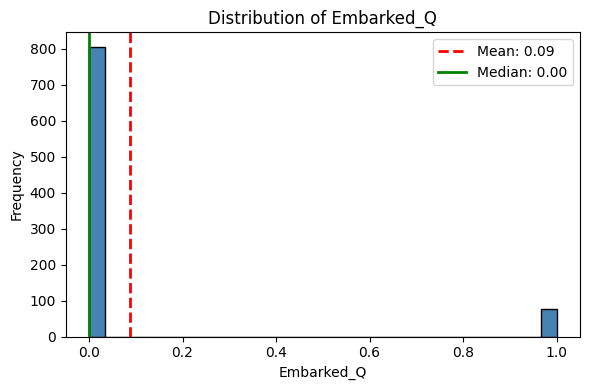

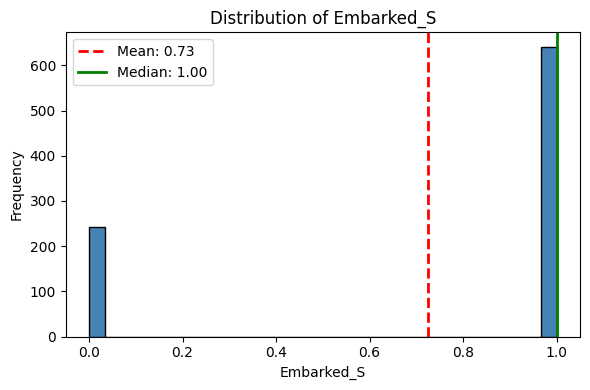

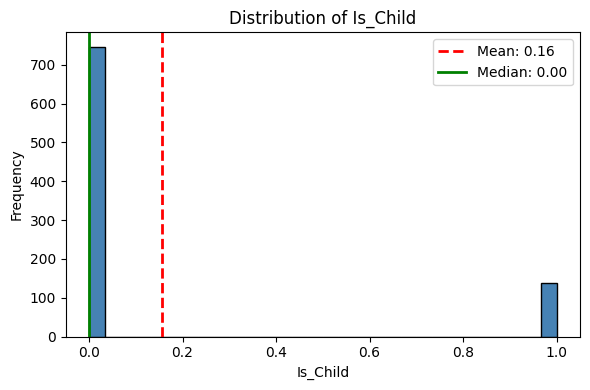

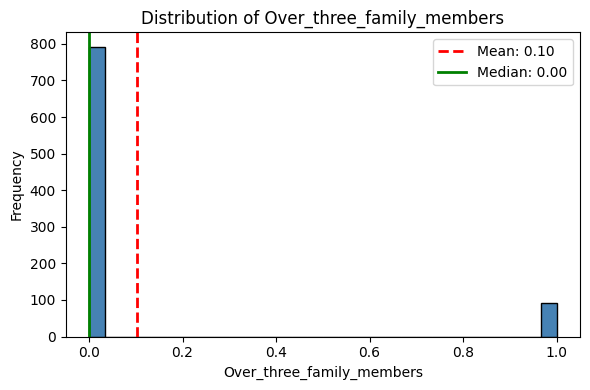

In [146]:
for column in titanic_df.columns:
    plot_numeric_histogram(titanic_df, column)

### Macierz korelacji

Ciekawą obserwacją jest to, że ilość kabin jest skorelowana z literą (co może oznaczać, że dalsze litery były przeznaczone dla ludzi w najwyższej klasie). Dodatkowo widzimy, że im dalsza litera, tym większe numery kabin oraz im większa opłata, tym większa ilość posiadanych kabin.

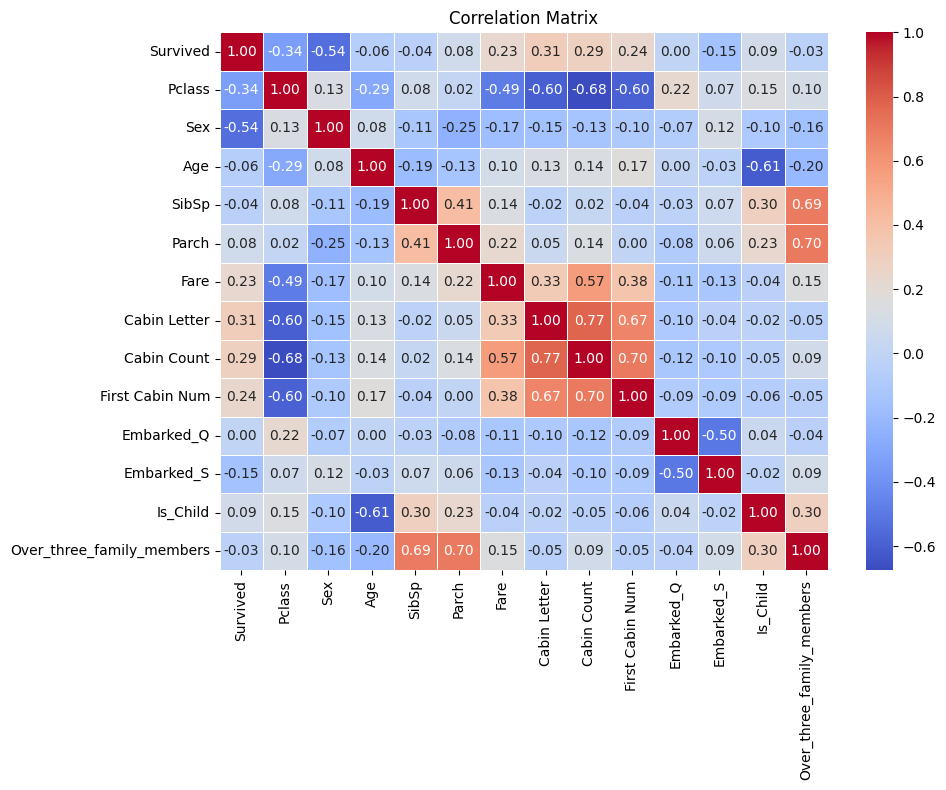

In [147]:
plot_correlation_matrix(titanic_df)

###Podział zbioru na labele i cechy

In [150]:
y = titanic_df['Survived']
X = titanic_df.drop(columns=['Survived'])